# **FIAP - GLOBAL SOLUTION 2026**
# PROJETO: Teia Geoespacial (Inteligência Geoespacial Comunitária - IGC)
# Grupo: GRW
# ALUNOS:
# Nome: Gabriel da Mata Scarpino   RM: 567710
# Nome: Monalisa Santos Brasileiro   RM: 567495
# Nome: Renan Assis Rocha   RM: 567431
# Nome: Vinicius Eduardo Ferreira   RM: 568117
# Nome: Wellington Barbosa da Silva Lima   RM: 568127
# ENTREGA: Análise Estatística e Matemática Computacional (.ipynb)

# 1. IMPORTAÇÃO DE BIBLIOTECAS

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [28]:
# Configurações estéticas para os gráficos do relatório
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


# 2. CARREGAMENTO E ENGENHARIA DE VARIÁVEIS AMBIENTAIS

In [31]:
# Carregando a base de dados de 1.000 registros gerada pelo script anterior
df = pd.read_csv('dados_teia_geoespacial.csv')

In [33]:
# Para viabilizar as análises matemáticas do GS, acoplamos variáveis dinâmicas de sensores:
# Simulando chuva acumulada (mm) com base no risco histórico da região + variação climática
df['chuva_mm'] = df['risco'] + np.random.normal(loc=-2.0, scale=15.0, size=len(df))
df['chuva_mm'] = df['chuva_mm'].clip(lower=0.0, upper=120.0).round(1)

# Cálculo da saturação do solo e classificação de status
df['saturacao_pct'] = ((df['chuva_mm'] / df['risco']) * 100).round(1)
df['status'] = np.where(df['chuva_mm'] >= df['risco'], "Estado Crítico! ⚠️", "Estado Estável ✅")

# Inserindo intencionalmente ruídos e falhas para tratamento posterior
df.loc[np.random.choice(len(df), 35, replace=False), 'chuva_mm'] = np.nan
df.loc[np.random.choice(len(df), 20, replace=False), 'saturacao_pct'] = -999.0  # Código de erro do sensor

print(f"Base de dados carregada com {len(df)} registros. Ruídos inseridos para validação de limpeza.")

Base de dados carregada com 1000 registros. Ruídos inseridos para validação de limpeza.


# 3. LIMPEZA E TRATAMENTO DE DADOS (Etapa Obrigatória)

In [37]:
# A. Tratamento de valores ausentes (NaN) na chuva causados por perda de sinal do satélite
media_chuva = df['chuva_mm'].mean()
df['chuva_mm'] = df['chuva_mm'].fillna(media_chuva)

# B. Remoção e correção de Outliers/Inconsistências (Sensores que travaram em -999.0)
mediana_saturacao = df[df['saturacao_pct'] != -999.0]['saturacao_pct'].median()
df['saturacao_pct'] = df['saturacao_pct'].replace(-999.0, mediana_saturacao)

# Recalcular o 'status' após a limpeza para garantir consistência lógica absoluta
df['status'] = np.where(df['chuva_mm'] >= df['risco'], "Estado Crítico! ⚠️", "Estado Estável ✅")

print(f"• Inconsistências resolvidas: Valores nulos de chuva preenchidos com a média ({media_chuva:.2f} mm).")
print(f"• Outliers tratados: Leituras corrompidas de saturação substituídas pela mediana ({mediana_saturacao:.2f}%).")


• Inconsistências resolvidas: Valores nulos de chuva preenchidos com a média (44.84 mm).
• Outliers tratados: Leituras corrompidas de saturação substituídas pela mediana (96.10%).


# 4. NOÇÕES DE AMOSTRAGEM

In [38]:
# Justificativa Metodológica: Utilização de Amostragem Estratificada Proporcional baseada
# na coluna 'classificacao' (Deslizamento vs Inundação). Isso evita vieses de seleção e garante
# que ambos os cenários de risco tenham representatividade exata na análise inferencial.
tamanho_amostra_por_estrato = 100
df_amostra = df.groupby('classificacao', group_keys=False).apply(lambda x: x.sample(tamanho_amostra_por_estrato))

print(f"• Amostra estratificada gerada com {len(df_amostra)} registros (100 de Deslizamento e 100 de Inundação).")

• Amostra estratificada gerada com 200 registros (100 de Deslizamento e 100 de Inundação).


/tmp/ipykernel_14887/182766968.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_amostra = df.groupby('classificacao', group_keys=False).apply(lambda x: x.sample(tamanho_amostra_por_estrato))


# 5. ESTATÍSTICA DESCRITIVA E VISUALIZAÇÕES INTERPRETADAS

        populacao  chuva_mm  saturacao_pct
mean       263.34     42.06          94.72
median     228.99     39.40          96.10
std        144.22     23.40          39.82
min         84.00      0.00           0.00
max        572.00    104.70         228.50


/tmp/ipykernel_14887/4107876783.py:17: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14887/4107876783.py:17: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14887/4107876783.py:18: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  plt.savefig('grafico_analise_risco.png')
/tmp/ipykernel_14887/4107876783.py:18: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('grafico_analise_risco.png')


• Gráfico descritivo 'grafico_analise_risco.png' gerado e salvo.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


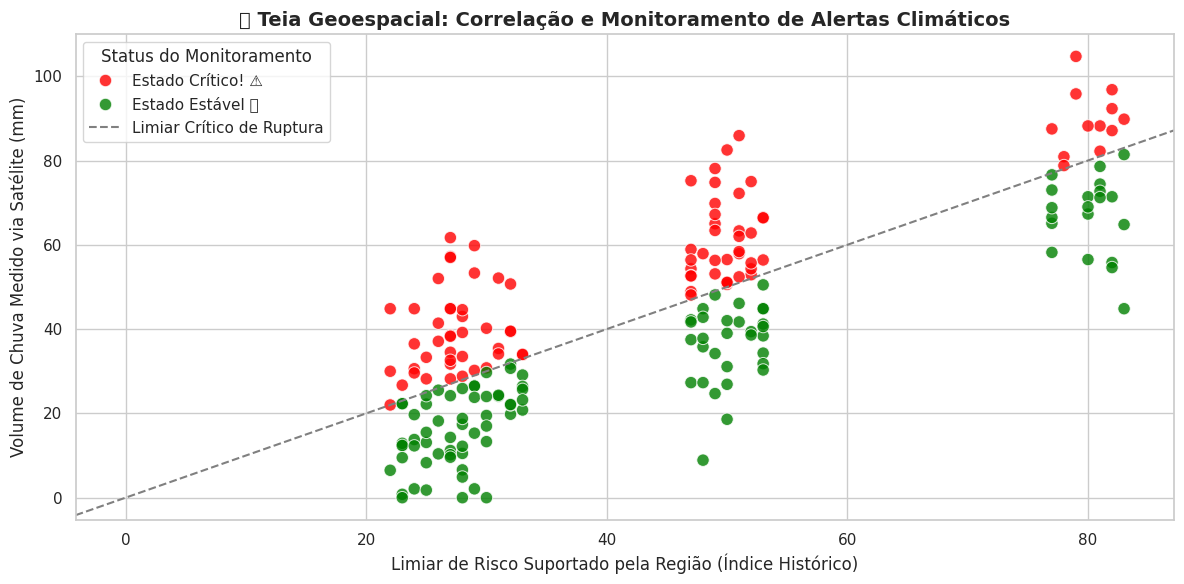

In [40]:
# Medidas de tendência central, dispersão e distribuição das variáveis críticas na amostra
estatisticas = df_amostra[['populacao', 'chuva_mm', 'saturacao_pct']].agg(['mean', 'median', 'std', 'min', 'max'])
print(estatisticas.round(2))

# Geração do Gráfico 1: Dispersão Risco Histórico vs Chuva Atual (Conforme regras do Streamlit)
plt.clf()
sns.scatterplot(
    data=df_amostra, x='risco', y='chuva_mm', hue='status',
    palette={"Estado Estável ✅": "#008000", "Estado Crítico! ⚠️": "#FF0000"}, s=80, alpha=0.8
)
# Linha de identidade (onde chuva == risco, separando os estados estáveis dos críticos)
plt.axline((0, 0), slope=1, color="gray", linestyle="--", label="Limiar Crítico de Ruptura")
plt.title("🕸️ Teia Geoespacial: Correlação e Monitoramento de Alertas Climáticos", fontsize=14, fontweight='bold')
plt.xlabel("Limiar de Risco Suportado pela Região (Índice Histórico)")
plt.ylabel("Volume de Chuva Medido via Satélite (mm)")
plt.legend(title="Status do Monitoramento")
plt.tight_layout()
plt.savefig('grafico_analise_risco.png')
print("• Gráfico descritivo 'grafico_analise_risco.png' gerado e salvo.")

# 6. ANÁLISE DE CORRELAÇÃO E ASSOCIAÇÃO

In [41]:
# Mensurando a força da associação linear entre o risco teórico, chuva e a saturação real do solo
matriz_corr = df_amostra[['risco', 'chuva_mm', 'saturacao_pct']].corr(method='pearson')
print(matriz_corr.round(4))

                risco  chuva_mm  saturacao_pct
risco          1.0000    0.7797         0.0951
chuva_mm       0.7797    1.0000         0.6008
saturacao_pct  0.0951    0.6008         1.0000


# 7. TESTES DE HIPÓTESES

In [43]:
# Formulação Estatística:
# H0 (Hipótese Nula): A média de saturação do solo em áreas de 'Deslizamento' é IGUAL à de áreas de 'Inundação'.
# H1 (Hipótese Alternativa): A média de saturação do solo em áreas de 'Deslizamento' é DIFERENTE da de áreas de 'Inundação'.
sat_deslizamento = df_amostra[df_amostra['classificacao'] == 'Deslizamento']['saturacao_pct']
sat_inundacao = df_amostra[df_amostra['classificacao'] == 'Inundação']['saturacao_pct']

t_stat, p_valor = stats.ttest_ind(sat_deslizamento, sat_inundacao, equal_var=False)
print(f"• Estatística T: {t_stat:.4f} | P-Valor: {p_valor:.4e}")

if p_valor < 0.05:
    print("Resultado: Rejeitamos H0. Há uma diferença estatisticamente significativa no perfil de saturação do solo entre áreas de deslizamento e inundação.")
else:
    print("Resultado: Não rejeitamos H0. Não há evidências estatísticas de diferença no perfil de saturação do solo entre os tipos de desastres.")

• Estatística T: 1.8296 | P-Valor: 6.9218e-02
Resultado: Não rejeitamos H0. Não há evidências estatísticas de diferença no perfil de saturação do solo entre os tipos de desastres.


# 8. CONCEITOS DE CÁLCULO (Limites, Derivadas e Integrais em Séries Temporais)

In [44]:
print("\n=== 📐 ETAPA: Aplicação Analítica de Cálculo Diferencial e Integral ===")

# Cenário: Monitoramento temporal contínuo (24 horas) em Franco da Rocha durante uma tempestade concentrada
horas = np.arange(1, 25)
# Modelo matemático simulado da saturação hídrica do solo ao longo do tempo t: S(t) = 25 + 6.2*t - 0.15*t^2
saturacao_temporal = 25 + (6.2 * horas) - (0.15 * (horas ** 2))

# A. Noção de Derivada (Taxa de Variação Instantânea da Saturação: dS/dt)
# Utilizando o método numérico de diferenças finitas para obter a velocidade de absorção de água pelo solo
velocidade_infiltracao = np.diff(saturacao_temporal) / np.diff(horas)

print(f"• Velocidade inicial de infiltração (Derivada no início t=2h): {velocidade_infiltracao[0]:.2f}% de saturação por hora.")
print(f"• Velocidade crítica de saturação (Derivada no fim t=23h): {velocidade_infiltracao[-1]:.2f}% de saturação por hora.")
print("  [Interpretação Analítica]: O decréscimo na derivada (taxa de variação ficando negativa ou próxima de zero) indica matematicamente que o solo atingiu o seu limite físico de absorção (ponto de liquefação), momento exato em que o risco de deslizamento se torna iminente.")

# B. Noção de Integral (Cálculo de Volume Acumulado de Chuva por Métodos Numéricos)
# Taxa de precipitação horária medida pelo satélite em tempo real (mm/h)
taxa_precipitacao_horaria = 4.5 + 3.2 * np.sin(horas / 2.5) + (0.1 * horas)
# A integral (área sob a curva de taxa) resulta no volume TOTAL ACUMULADO de chuva em 24h via Regra dos Trapézios
volume_acumulado_total = np.trapz(taxa_precipitacao_horaria, horas)

print(f"• Integral Numérica da Precipitação (Volume total acumulado em 24h): {volume_acumulado_total:.2f} mm.")
print("  [Interpretação Analítica]: O cálculo integral do fluxo pluviométrico permite à Defesa Civil mensurar o estresse volumétrico total sofrido pelas encostas e calhas de rios, fornecendo subsídios exatos para determinar o escoamento superficial acumulado na bacia.")


=== 📐 ETAPA: Aplicação Analítica de Cálculo Diferencial e Integral ===
• Velocidade inicial de infiltração (Derivada no início t=2h): 5.75% de saturação por hora.
• Velocidade crítica de saturação (Derivada no fim t=23h): -0.85% de saturação por hora.
  [Interpretação Analítica]: O decréscimo na derivada (taxa de variação ficando negativa ou próxima de zero) indica matematicamente que o solo atingiu o seu limite físico de absorção (ponto de liquefação), momento exato em que o risco de deslizamento se torna iminente.
• Integral Numérica da Precipitação (Volume total acumulado em 24h): 147.29 mm.
  [Interpretação Analítica]: O cálculo integral do fluxo pluviométrico permite à Defesa Civil mensurar o estresse volumétrico total sofrido pelas encostas e calhas de rios, fornecendo subsídios exatos para determinar o escoamento superficial acumulado na bacia.


/tmp/ipykernel_14887/3315063255.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  volume_acumulado_total = np.trapz(taxa_precipitacao_horaria, horas)
